# mechanism_viewer examples

## Use correlation to profile the missing data

This notebook contains examples of how to use `missing_columns_correlation()` and `complete_and_missing_columns_correlation()` from `viewer_correlation.py`. Both functions use correlation to perceive the missingness pattern of each column. For example, if one square reveals a high correlation value, then it is possible that the pair of columns has some kind of relation that makes the missingness not random.

> Note: Correlation plots are exploratory. They should be used together with more checks before concluding the missing data mechanism of columns.

### 1. Generate synthetic datasets with missing values

In this notebook, one dataset will be used to demonstrate the functions inside `viewer_correlation.py`. This dataset contains a mixture of missing data mechanisms and missing rates.

In [1]:
from mechanism_viewer import generate_dataset_with_missing_data, ColType

data = generate_dataset_with_missing_data(200, [ColType.DISCRETE, ColType.CONTINUOUS, ColType.CONTINUOUS,
                                           ColType.CONTINUOUS, ColType.CONTINUOUS], 1, ["MCAR", "MAR",
                                           "MCAR", "MNAR"], [0.2, 0.35, 0.4, 0.3])

display(data.head(10))

,Col1,Col2,Col3,Col4,Col5
0,8,-1.507326,NaN,-1.146832,-1.057155
1,7,-0.985158,NaN,-0.940221,-1.051887
2,7,-0.860842,NaN,NaN,-0.144284
3,2,2.457424,-1.126988,-1.163474,-1.216718
4,6,1.801742,1.328631,0.162060,NaN
5,3,-0.411749,1.245635,0.729716,-0.917754
6,8,-0.363583,NaN,-1.587098,NaN
7,3,-1.149204,-1.514755,0.025129,-0.451384
8,7,-1.908130,NaN,-0.219936,0.072018
9,8,-0.116880,NaN,0.341509,-1.295341


### 2. Correlation between missing columns with `missing_columns_correlation()`

This function plots the correlation matrix for columns that contain missing values.
Essentially, values close to 1 suggest similar missingness behavior between two missing columns.

The function returns a `(figure, axis)` tuple, so that the user can adapt the plot to their wish. In addition, by setting `display_plot=True`, the function will also display the plot inside the notebook.

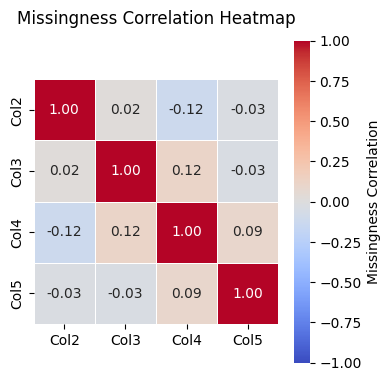

In [2]:
from mechanism_viewer import missing_columns_correlation

fig_miss_corr, ax_miss_corr = missing_columns_correlation(data, display_plot=True)

The results suggest that no particular missing column has missingness correlation with other missing columns. This means that each missing column has its missing values for different reasons/dependencies.

### 3. Correlation with complete + missing columns

`complete_and_missing_columns_correlation()` computes the standard correlation for complete columns, but when a column contains missing data, the correlation is instead calculated using its missingness indicator (whether a value is missing or not) rather than the actual values. This helps to explore whether complete columns are associated with the missingness behavior in the missing columns.

The function also returns a `(figure, axis)` tuple, and has the option of setting `display_plot=True` to display the plot in the notebook.

>Note: While this function performs well when columns contain independent information, caution is needed when a column’s values depend on other variables before missingness is introduced. In such cases, high correlations may simply reflect value dependency rather than a true relationship with the missingness mechanism. Therefore, additional testing is recommended to determine whether the correlated columns genuinely influence the missingness pattern. Check use case `cancer.ipynb` for an example in how to explore this dependency.

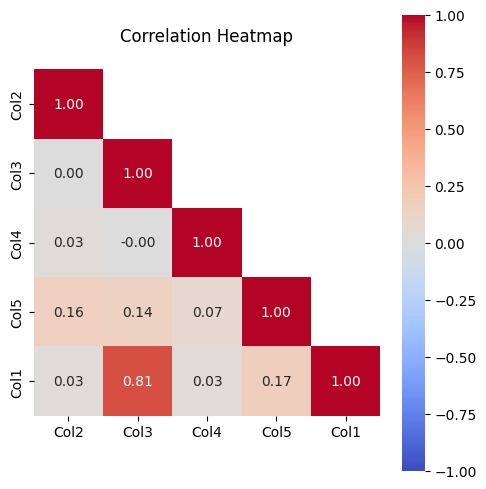

In [3]:
from mechanism_viewer import complete_and_missing_columns_correlation

fig_comp_corr, ax_comp_corr = complete_and_missing_columns_correlation(data, display_plot=True)

The results indicate that Col3 is dependent on Col1 for its missing values, which is consistent with a MAR missing data mechanism.

Meanwhile, other columns do not seem to have their missingness correlated to complete columns.

### 4. Correlation between 1 missing column and every other column

In datasets with a large number of columns, identifying which correlations truly matter for understanding missing‑data mechanisms can become difficult, especially when heatmaps display dense grids of colorful values.

To address this, ``missing_vs_all_correlation()`` focuses on a single missing column at a time. It computes the correlation between that column's missingness and the actual values of every other column, regardless of whether those columns contain missing data.

This is useful because earlier heatmaps correlate two missing columns using both of their missingness patterns, which can obscure how the missingness of one column relates to the underlying values of others. By isolating this relationship, the function allows a more accurate assessment of how a column's missingness depends on the rest of the dataset.

Moreover, the function returns a `(figure, axis)` tuple, and has the option of setting `display_plot=True` to display the plot in the notebook.

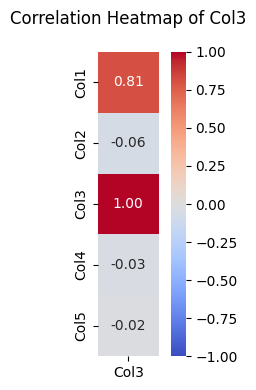

In [4]:
from mechanism_viewer import missing_vs_all_correlation

fig_vs_corr, ax_vs_corr = missing_vs_all_correlation(data, missing_col="Col3" , display_plot=True)

The results confirms that Col3 is dependent on Col1 for its missing values, reinforcing the likelihood of having MAR as the missing-data mechanism.